### Collecting and processing data

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

df = pd.read_csv('dataset-47695.csv')

df.head()

,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,Prof,B,19,18,Male,139750
1,Prof,B,20,16,Male,173200
2,AsstProf,B,4,3,Male,79750
3,Prof,B,45,39,Male,115000
4,Prof,B,40,41,Male,141500


In [2]:
df.drop(['discipline', 'sex', 'yrs.service'],axis=1,inplace=True)
df.head(10)

,rank,yrs.since.phd,salary
0,Prof,19,139750
1,Prof,20,173200
2,AsstProf,4,79750
3,Prof,45,115000
4,Prof,40,141500
5,AssocProf,6,97000
6,Prof,30,175000
7,Prof,45,147765
8,Prof,21,119250
9,Prof,18,129000


In [3]:
df = df[df['rank'] == 'AssocProf']
df.to_csv('Salla.csv', index = False)

In [4]:
df.describe()

,yrs.since.phd,salary
count,64.000000,64.000000
mean,15.453125,93876.437500
std,9.652584,13831.699844
min,6.000000,62884.000000
25%,10.000000,82475.000000
50%,12.000000,95626.500000
75%,17.250000,104226.250000
max,49.000000,126431.000000


### Calculate mean, variance, and standard deviation

In [5]:
salary = df['salary'].tolist()
yrs_since_phd = df['yrs.since.phd'].tolist()
# numpy use population std, pandas use sample std
# if we use np with ddof = 1 => freedom degree
# the result will be the same as pandas

salary_mean = np.mean(salary)
salary_var = np.var(salary)
salary_std = np.std(salary)

print('Mean of salary: ', salary_mean)
print('Variance of salary: ', salary_var)
print('Std of salary: ', salary_std) 
print() 

yrs_since_phd_mean = np.mean(yrs_since_phd)
yrs_since_phd_var = np.var(yrs_since_phd)
yrs_since_phd_std = np.std(yrs_since_phd)

print('Mean of yrs_since_phd: ', yrs_since_phd_mean)
print('Variance of yrs_since_phd: ', yrs_since_phd_var)
print('Std of yrs_since_phd: ', yrs_since_phd_std)



Mean of salary:  93876.4375
Variance of salary:  188326609.30859375
Std of salary:  13723.21424844026

Mean of yrs_since_phd:  15.453125
Variance of yrs_since_phd:  91.716552734375
Std of yrs_since_phd:  9.576875938132174


### Visualize experience and salary

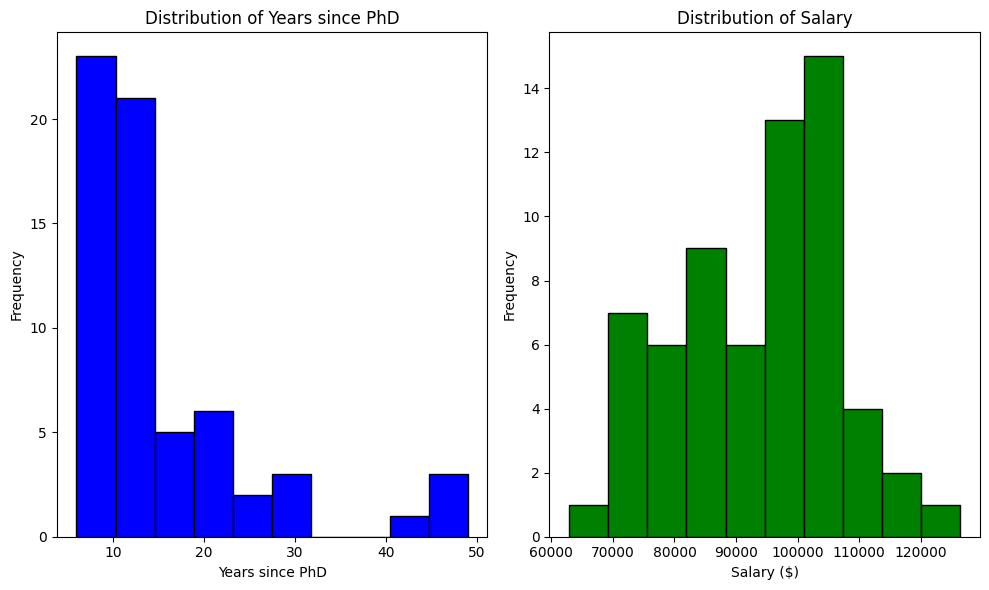

In [6]:
import matplotlib.pyplot as plt

salary = df['salary'].tolist()
yrs_since_phd = df['yrs.since.phd'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

ax1.hist(yrs_since_phd, bins=10, color='blue', edgecolor='black')
ax1.set_xlabel('Years since PhD')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Years since PhD')

ax2.hist(salary, bins=10, color='green', edgecolor='black')
ax2.set_xlabel('Salary ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Salary')

plt.tight_layout()
plt.show()


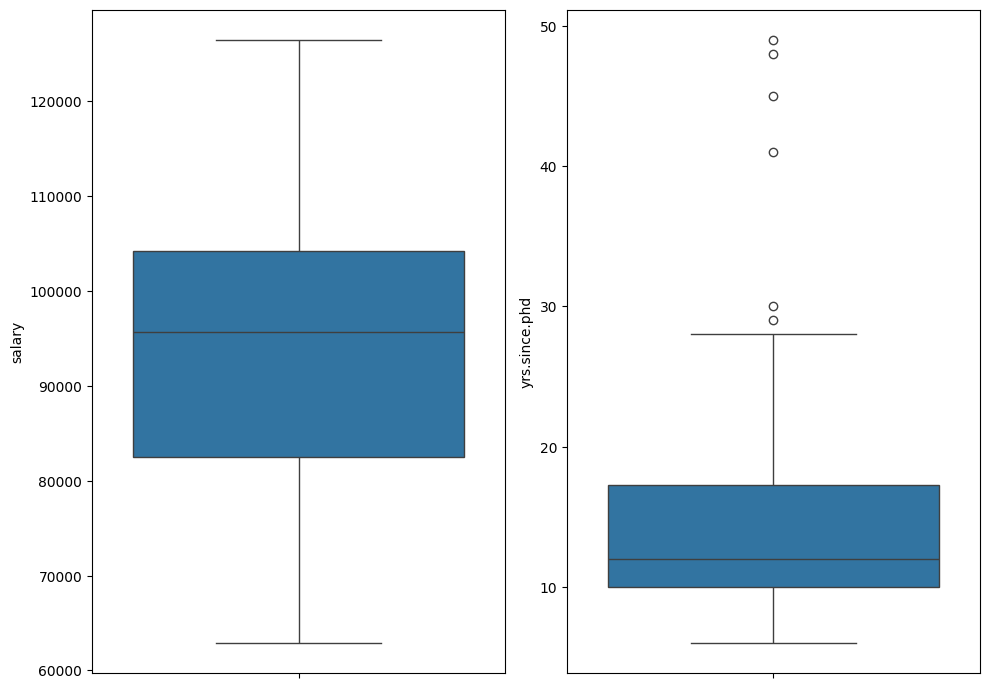

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 7))

plt1 = sns.boxplot(y = df['salary'], ax = axs[0])
plt2 = sns.boxplot(y = df['yrs.since.phd'], ax = axs[1])
plt.tight_layout()
plt.show()

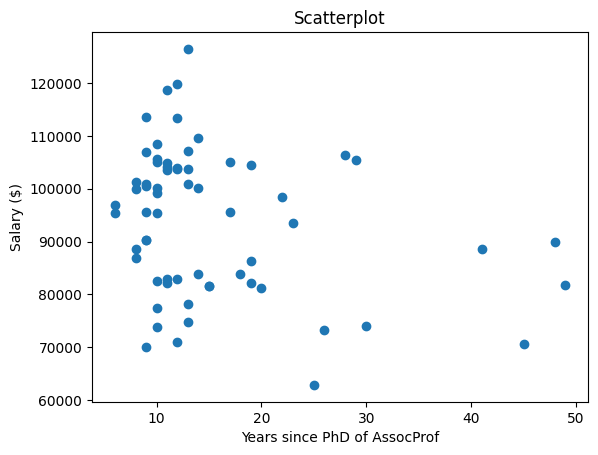

In [8]:
plt.scatter(x = df['yrs.since.phd'], y = df['salary']) 
plt.title('Scatterplot')
plt.xlabel('Years since PhD of AssocProf')
plt.ylabel('Salary ($)')
plt.show()

### Testing the hypothesis

In [9]:
import scipy.stats as stats
# assume that Null hypothesis: Mean of Salary of AssocProf in US is 130000$ 
# = > Alternative hypothesis: Mean of Salary of AssocProf in US is not 130000$
# CI = 95% or 0.95
data = df['salary'].tolist()

#perform one sample t-test
stats.ttest_1samp(a=data, popmean=130000)

# after calculate we get p-value = 5.05e-30 << 0.05
# => accept the null hypothesis and reject alternative hypothesis.

TtestResult(statistic=-20.89320208395668, pvalue=5.052559587156717e-30, df=63)

### Linear Regression Model

In [10]:
from sklearn.model_selection import train_test_split

X = df['yrs.since.phd']
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=1)

In [11]:
print(X_train)
print(y_train.shape)

92     10
158     6
156    12
217    29
334    19
255    12
107    10
382     8
111    19
140    14
55     14
227     9
57      9
370    13
10     12
104    18
5       6
96     17
54     12
65      9
60      9
58     10
89      9
218    14
188    28
Name: yrs.since.phd, dtype: int64
(25,)


In [12]:
X_train = np.array(X_train).reshape(-1, 1)
y_train = np.array(y_train).reshape(-1, 1)
X_test = np.array(X_test).reshape(-1, 1)

# Reshape your data either using array.reshape(-1, 1) if your data has a single feature 
# or array.reshape(1, -1) if it contains a single sample.

print(X_train)  
print(y_train.shape)
print(X_test.shape)

[[10]
 [ 6]
 [12]
 [29]
 [19]
 [12]
 [10]
 [ 8]
 [19]
 [14]
 [14]
 [ 9]
 [ 9]
 [13]
 [12]
 [18]
 [ 6]
 [17]
 [12]
 [ 9]
 [ 9]
 [10]
 [ 9]
 [14]
 [28]]
(25, 1)
(39, 1)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [14]:
y_prediction = model.predict(X_test)
print(y_prediction)

[[ 94646.28835597]
 [108798.26350766]
 [ 95018.7087547 ]
 [ 95391.12915342]
 [ 95763.54955215]
 [ 95763.54955215]
 [100232.5943369 ]
 [ 95018.7087547 ]
 [ 95018.7087547 ]
 [ 93901.44755851]
 [ 97998.07194452]
 [ 95391.12915342]
 [ 93901.44755851]
 [ 96508.39034961]
 [ 94646.28835597]
 [106191.32071656]
 [ 94273.86795724]
 [ 94273.86795724]
 [ 95763.54955215]
 [ 95018.7087547 ]
 [ 95763.54955215]
 [ 96508.39034961]
 [ 95763.54955215]
 [ 94646.28835597]
 [ 95018.7087547 ]
 [ 94273.86795724]
 [107681.00231147]
 [102094.69633054]
 [ 94646.28835597]
 [109170.68390639]
 [ 93901.44755851]
 [ 98370.49234325]
 [ 94646.28835597]
 [ 95018.7087547 ]
 [ 97253.23114707]
 [ 99115.33314071]
 [100605.01473563]
 [ 94646.28835597]
 [ 99487.75353944]]


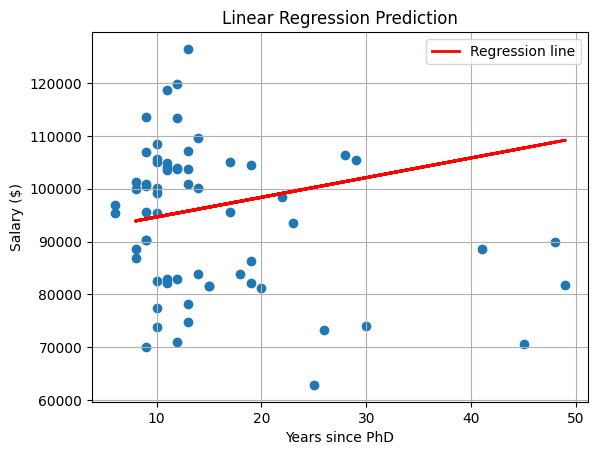

In [15]:
plt.scatter(x=df['yrs.since.phd'], y=df['salary'])

plt.plot(X_test, y_prediction, color='red', linewidth=2, label='Regression line')

plt.xlabel('Years since PhD')
plt.ylabel('Salary ($)')
plt.title('Linear Regression Prediction')
plt.legend()
plt.grid(True)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_prediction)
mse = mean_squared_error(y_test, y_prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_prediction)


print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R^2 (Coefficient of Determination): {r2}")

Mean Absolute Error (MAE): 14500.335437364327
Mean Squared Error (MSE): 298995225.69316053
Root Mean Squared Error (RMSE): 17291.478412592733
R^2 (Coefficient of Determination): -0.40956221522525516
